<a href="https://colab.research.google.com/github/rafael-guimaraes/calculo-numerico/blob/main/Atividade_01/Atividade_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade I - Cálculo Numérico - Noturno - Profa. Dra. Raquel Lobosco

Nome: Rafael Augusto Guimaraes da Silva


Nome: Joao Pedro Araujo Costa

## Divisão das tarefas

Rafael Augusto Guimaraes da Silva: Parte A, Parte B, a Parte D.2 (precisão computacional e cancelamento) e o GIF demonstrativo.

Joao Pedro Araujo Costa: Parte C, a Parte D.1 e a D.3, e o quadro único de resultados da Parte E.

Os dois: funções de erro, discussão dos gráficos e conclusão.

# CONFIGURAÇÃO PADRÃO

In [1]:

# Importa a biblioteca de funções matemáticas da linguagem Python.
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.
import numpy as np

# Importa o módulo de gráficos pyplot e cria o apelido plt.
import matplotlib.pyplot as plt

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Exibe uma mensagem para confirmar que a célula foi executada.
print("Ambiente preparado com sucesso!")


Ambiente preparado com sucesso!


# Parte A - Truncamento e Arredondamento

In [2]:
valores = []
valores.append(3.14159265)
valores.append(98.76543)
valores.append(0.00498765)


def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator
for j in range(3):
  print(f"Truncamento e arredondamento do valor: {valores[j]}")
  for i in range(5):
    print(f"truncar({valores[j]}, {i}) = {truncar(valores[j], i)}")
    print(f"round({valores[j]}, {i}) = {round(valores[j],i)}")
  print()


Truncamento e arredondamento do valor: 3.14159265
truncar(3.14159265, 0) = 3.0
round(3.14159265, 0) = 3.0
truncar(3.14159265, 1) = 3.1
round(3.14159265, 1) = 3.1
truncar(3.14159265, 2) = 3.14
round(3.14159265, 2) = 3.14
truncar(3.14159265, 3) = 3.141
round(3.14159265, 3) = 3.142
truncar(3.14159265, 4) = 3.1415
round(3.14159265, 4) = 3.1416

Truncamento e arredondamento do valor: 98.76543
truncar(98.76543, 0) = 98.0
round(98.76543, 0) = 99.0
truncar(98.76543, 1) = 98.7
round(98.76543, 1) = 98.8
truncar(98.76543, 2) = 98.76
round(98.76543, 2) = 98.77
truncar(98.76543, 3) = 98.765
round(98.76543, 3) = 98.765
truncar(98.76543, 4) = 98.7654
round(98.76543, 4) = 98.7654

Truncamento e arredondamento do valor: 0.00498765
truncar(0.00498765, 0) = 0.0
round(0.00498765, 0) = 0.0
truncar(0.00498765, 1) = 0.0
round(0.00498765, 1) = 0.0
truncar(0.00498765, 2) = 0.0
round(0.00498765, 2) = 0.0
truncar(0.00498765, 3) = 0.004
round(0.00498765, 3) = 0.005
truncar(0.00498765, 4) = 0.0049
round(0.00498765

In [3]:
def erro_absoluto(exato, aproximado):
    # Diferenca em modulo entre o valor de referencia e a aproximacao.
    return abs(exato - aproximado)


def erro_relativo(exato, aproximado):
    # Erro absoluto dividido pelo modulo do valor de referencia.
    if exato == 0: return 0
    return erro_absoluto(exato, aproximado) / abs(exato)


def erro_percentual(exato, aproximado):
    # Erro relativo escrito em porcentagem.
    return erro_relativo(exato, aproximado) * 100

casas = [0, 1, 2, 3, 4]
tabela_A = []

for x in valores:
    for n in casas:
        x_tru = truncar(x, n)
        x_arr = round(x, n)

        tabela_A.append({
            "x": x,
            "n": n,
            "Truncado": x_tru,
            "Ea_tru": erro_absoluto(x, x_tru),
            "Er_tru": erro_relativo(x, x_tru),
            "Ep_tru": erro_percentual(x, x_tru),
            "Arredondado": x_arr,
            "Ea_arr": erro_absoluto(x, x_arr),
            "Er_arr": erro_relativo(x, x_arr),
            "Ep_arr": erro_percentual(x, x_arr)
        })

for x in valores:
    print(f"--- Valor de referencia x = {x} (grandeza adimensional) ---")
    print(f"{'n':<3} | {'Truncado':<13} | {'Ea (tru)':<11} | {'Er (tru)':<11} | {'E% (tru)':<11} | {'Arredondado':<13} | {'Ea (arr)':<11} | {'Er (arr)':<11} | {'E% (arr)':<11}")
    print("-" * 125)

    for linha in tabela_A:
        if linha["x"] != x: continue
        print(f"{linha['n']:<3} | {linha['Truncado']:<13.5f} | {linha['Ea_tru']:<11.3e} | {linha['Er_tru']:<11.3e} | {linha['Ep_tru']:<11.5f} | {linha['Arredondado']:<13.5f} | {linha['Ea_arr']:<11.3e} | {linha['Er_arr']:<11.3e} | {linha['Ep_arr']:<11.5f}")

    print()

--- Valor de referencia x = 3.14159265 (grandeza adimensional) ---
n   | Truncado      | Ea (tru)    | Er (tru)    | E% (tru)    | Arredondado   | Ea (arr)    | Er (arr)    | E% (arr)   
-----------------------------------------------------------------------------------------------------------------------------
0   | 3.00000       | 1.416e-01   | 4.507e-02   | 4.50703     | 3.00000       | 1.416e-01   | 4.507e-02   | 4.50703    
1   | 3.10000       | 4.159e-02   | 1.324e-02   | 1.32394     | 3.10000       | 4.159e-02   | 1.324e-02   | 1.32394    
2   | 3.14000       | 1.593e-03   | 5.070e-04   | 0.05070     | 3.14000       | 1.593e-03   | 5.070e-04   | 0.05070    
3   | 3.14100       | 5.927e-04   | 1.886e-04   | 0.01886     | 3.14200       | 4.073e-04   | 1.297e-04   | 0.01297    
4   | 3.14150       | 9.265e-05   | 2.949e-05   | 0.00295     | 3.14160       | 7.350e-06   | 2.340e-06   | 0.00023    

--- Valor de referencia x = 98.76543 (grandeza adimensional) ---
n   | Truncado      |

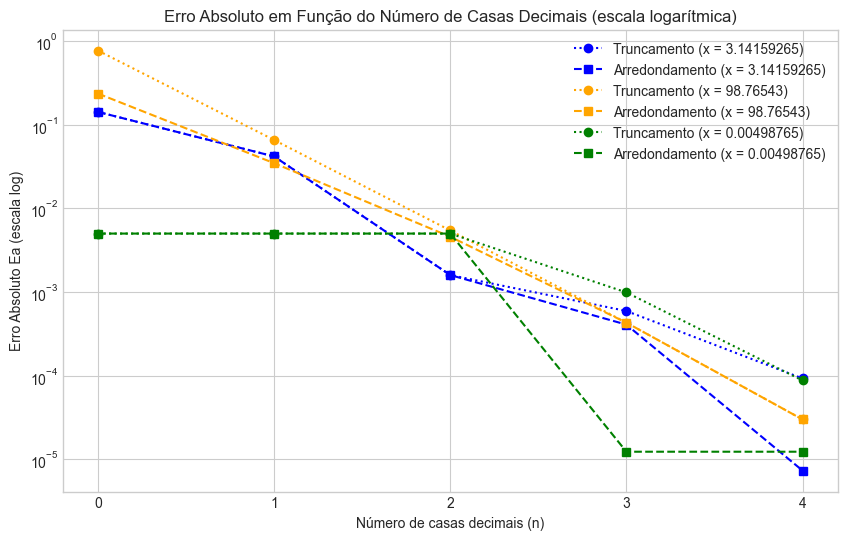

In [4]:
plt.figure(figsize=(10, 6))

cores = ['blue', 'orange', 'green']

for j in range(3):
    x = valores[j]

    # Monta as duas curvas de erro absoluto para o mesmo valor de referencia.
    ea_tru = [erro_absoluto(x, truncar(x, n)) for n in casas]
    ea_arr = [erro_absoluto(x, round(x, n)) for n in casas]

    plt.semilogy(casas, ea_tru, color=cores[j], marker='o', linestyle=':', label=f'Truncamento (x = {x})')
    plt.semilogy(casas, ea_arr, color=cores[j], marker='s', linestyle='--', label=f'Arredondamento (x = {x})')

plt.title('Erro Absoluto em Função do Número de Casas Decimais (escala logarítmica)')
plt.xlabel('Número de casas decimais (n)')
plt.ylabel('Erro Absoluto Ea (escala log)')
plt.xticks(casas)
plt.legend()
plt.grid(True)
plt.show()

Arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os resultados.

Sim. Olhando a tabela, para todo valor e para todo n, o Ea do arredondamento nunca é maior que o do truncamento. Isso acontece porque o truncamento joga fora tudo que vem depois da casa n, então o erro é essa sobra inteira, que pode chegar perto de 10^-n. Já o arredondamento pega o vizinho mais próximo, então o erro no máximo é a metade disso. Quando a sobra é pequena os dois dão o mesmo número e os erros ficam iguais, como em x = 3,14159265 com n = 0, 1 e 2. Quando a sobra é grande o arredondamento leva vantagem, como em x = 0,00498765 com n = 3, onde o truncamento erra 19,80% e o arredondamento erra só 0,25%. No gráfico em escala logarítmica também observamos que os dois erros caem mais ou menos uma década a cada casa decimal, mas a curva do arredondamento nunca fica acima da do truncamento.

# Parte B - Medidas de pressão arterial

## B.1 - Representação das medidas

In [5]:
dados_originais = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
dados_truncados = [truncar(i, 0) for i in dados_originais]
dados_arredondados = [round(i, 0) for i in dados_originais]

def media(valores):
	soma = 0
	cont = 0
	for i in valores:
		soma += i
		cont += 1

	if cont == 0: return 0
	return soma / cont


def amplitude(valores):
	# Diferenca entre a maior e a menor medida da serie.
	if len(valores) == 0: return 0
	return max(valores) - min(valores)


def desvio_padrao_amostral(valores):
	cont = 0
	for i in valores:
		cont += 1

	if cont <= 1: return 0

	med = media(valores)
	soma_quadrados = 0
	for i in valores:
		soma_quadrados += (i - med) ** 2

	variancia = soma_quadrados / (cont - 1)
	return variancia ** 0.5

series = {
	"Originais": dados_originais,
	"Truncados": dados_truncados,
	"Arredondados": dados_arredondados
}

for nome, dados in series.items():
	print(f"--- Série: {nome} ---")
	print(f"Mínimo: {min(dados):.4f} mmHg")
	print(f"Máximo: {max(dados):.4f} mmHg")
	print(f"Amplitude: {amplitude(dados):.4f} mmHg")
	print(f"Média: {media(dados):.4f} mmHg")
	print(f"Desvio Padrão (Amostral): {desvio_padrao_amostral(dados):.4f} mmHg\n")

--- Série: Originais ---
Mínimo: 119.8000 mmHg
Máximo: 122.4000 mmHg
Amplitude: 2.6000 mmHg
Média: 121.1200 mmHg
Desvio Padrão (Amostral): 0.8337 mmHg

--- Série: Truncados ---
Mínimo: 119.0000 mmHg
Máximo: 122.0000 mmHg
Amplitude: 3.0000 mmHg
Média: 120.7000 mmHg
Desvio Padrão (Amostral): 0.9487 mmHg

--- Série: Arredondados ---
Mínimo: 120.0000 mmHg
Máximo: 122.0000 mmHg
Amplitude: 2.0000 mmHg
Média: 121.1000 mmHg
Desvio Padrão (Amostral): 0.8756 mmHg



In [6]:
media_referencia = media(series["Originais"])

print(f"--- Erros da Média Aproximada (referência: média dos originais = {media_referencia:.4f} mmHg) ---")
print(f"{'Série':<15} | {'Média (mmHg)':<14} | {'Ea (mmHg)':<12} | {'Er':<12} | {'E% (%)':<12}")
print("-" * 76)

for nome, dados in series.items():
    med = media(dados)
    print(f"{nome:<15} | {med:<14.4f} | {erro_absoluto(media_referencia, med):<12.4f} | {erro_relativo(media_referencia, med):<12.6f} | {erro_percentual(media_referencia, med):<12.6f}")

--- Erros da Média Aproximada (referência: média dos originais = 121.1200 mmHg) ---
Série           | Média (mmHg)   | Ea (mmHg)    | Er           | E% (%)      
----------------------------------------------------------------------------
Originais       | 121.1200       | 0.0000       | 0.000000     | 0.000000    
Truncados       | 120.7000       | 0.4200       | 0.003468     | 0.346764    
Arredondados    | 121.1000       | 0.0200       | 0.000165     | 0.016513    


## B.2 - Gráficos obrigatórios

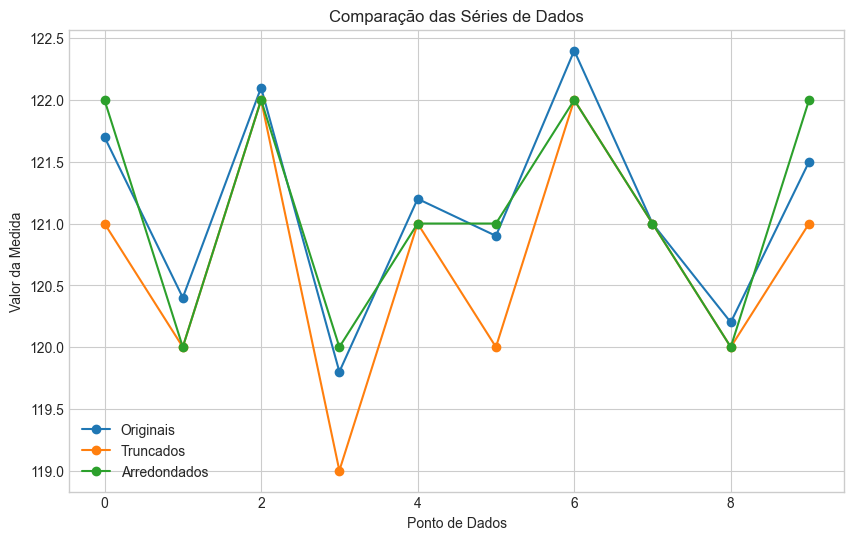

In [7]:
plt.figure(figsize=(10, 6))

for nome, dados in series.items():
    plt.plot(dados, label=nome, marker='o')

plt.title('Comparação das Séries de Dados')
plt.xlabel('Ponto de Dados')
plt.ylabel('Valor da Medida')
plt.legend()
plt.grid(True)
plt.show()

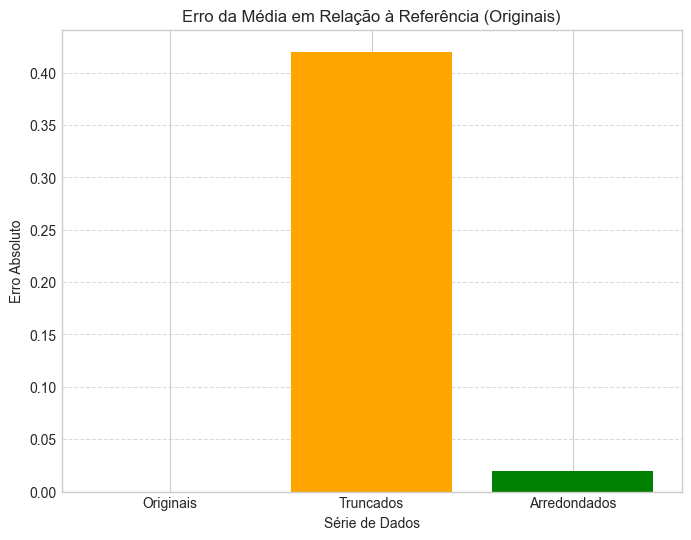

In [8]:
erros = {}
media_ref = media(series["Originais"])

for nome, dados in series.items():
    erros[nome] = abs(media(dados) - media_ref)

plt.figure(figsize=(8, 6))
plt.bar(erros.keys(), erros.values(), color=['blue', 'orange', 'green'])

plt.title('Erro da Média em Relação à Referência (Originais)')
plt.ylabel('Erro Absoluto')
plt.xlabel('Série de Dados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

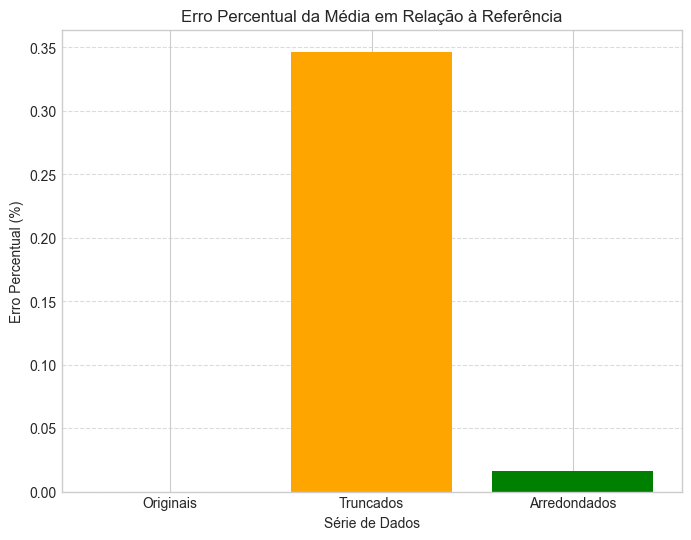

In [9]:
erros_percentuais = {}
media_ref = media(series["Originais"])

for nome, dados in series.items():
    erro_abs = abs(media(dados) - media_ref)
    erros_percentuais[nome] = (erro_abs / media_ref) * 100

plt.figure(figsize=(8, 6))
plt.bar(erros_percentuais.keys(), erros_percentuais.values(), color=['blue', 'orange', 'green'])

plt.title('Erro Percentual da Média em Relação à Referência')
plt.ylabel('Erro Percentual (%)')
plt.xlabel('Série de Dados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

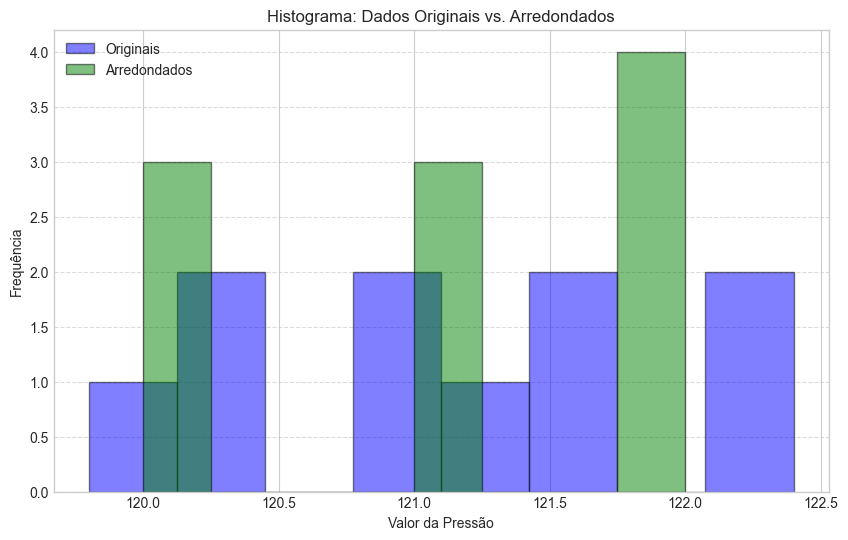

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(series['Originais'], bins=8, alpha=0.5, label='Originais', color='blue', edgecolor='black')
plt.hist(series['Arredondados'], bins=8, alpha=0.5, label='Arredondados', color='green', edgecolor='black')

plt.title('Histograma: Dados Originais vs. Arredondados')
plt.xlabel('Valor da Pressão')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Pelos gráficos obtidos, observamos que a variabilidade, que aparece no histograma, é bastante prejudicada, pois temos uma centralização dos valores nos pontos inteiros. Já na média observamos que a aproximação não causa um erro tão grande, especialmente na série arredondada, pois o arredondamento faz com que os valores não se alterem tanto e os erros acabam se anulando também. Pelos números, a média arredondada erra só 0,017%, mas a amplitude cai de 2,6 para 2,0 mmHg, então a representação inteira preserva a média mas não preserva a variabilidade desta amostra.

# Parte C - Vazão em um tubo de pequeno diâmetro

## C.1 - Precisão das variáveis

In [11]:
def calcularQ(r, L, mi, delta_p):
  # Relacao de Hagen-Poiseuille no SI: r e L em m, mi em Pa.s, delta_p em Pa.
  return math.pi * r**4 * delta_p / (8 * L * mi)

r = 0.80        # raio em mm
L = 0.20        # comprimento em m
mi = 3.5e-3     # viscosidade em Pa.s
delta_p = 1200  # diferenca de pressao em Pa

# As aproximacoes sao feitas nas unidades do enunciado (mm, Pa.s, Pa) e so
# depois o raio e convertido para metros na hora de aplicar a formula.
Q_original = calcularQ(r / 1000, L, mi, delta_p)

# Dicionário para armazenar todos os cenários de teste
scenarios = {
    "r Arredondado": calcularQ(round(r, 1) / 1000, L, mi, delta_p),
    "r Truncado": calcularQ(truncar(r, 1) / 1000, L, mi, delta_p),
    "mi Arredondado": calcularQ(r / 1000, L, round(mi, 3), delta_p),
    "mi Truncado": calcularQ(r / 1000, L, truncar(mi, 3), delta_p),
    "delta_p Arredondado": calcularQ(r / 1000, L, mi, round(delta_p, -2)),
    "delta_p Truncado": calcularQ(r / 1000, L, mi, truncar(delta_p, -2)),
    "Tudo Arredondado": calcularQ(round(r, 1) / 1000, L, round(mi, 3), round(delta_p, -2)),
    "Tudo Truncado": calcularQ(truncar(r, 1) / 1000, L, truncar(mi, 3), truncar(delta_p, -2))
}

print(f"Vazão Original (Referência): {Q_original:.6e} m³/s\n")

print(f"{'Cenário':<25} | {'Q (m³/s)':<14} | {'Ea (m³/s)':<14} | {'Er':<14} | {'E% (%)':<14}")
print("-" * 95)

for nome, Q_calc in scenarios.items():
    print(f"{nome:<25} | {Q_calc:<14.6e} | {erro_absoluto(Q_original, Q_calc):<14.6e} | {erro_relativo(Q_original, Q_calc):<14.6e} | {erro_percentual(Q_original, Q_calc):<14.6f}")

Vazão Original (Referência): 2.757421e-07 m³/s

Cenário                   | Q (m³/s)       | Ea (m³/s)      | Er             | E% (%)        
-----------------------------------------------------------------------------------------------
r Arredondado             | 2.757421e-07   | 0.000000e+00   | 0.000000e+00   | 0.000000      
r Truncado                | 2.757421e-07   | 0.000000e+00   | 0.000000e+00   | 0.000000      
mi Arredondado            | 2.412743e-07   | 3.446776e-08   | 1.250000e-01   | 12.500000     
mi Truncado               | 3.216991e-07   | 4.595701e-08   | 1.666667e-01   | 16.666667     
delta_p Arredondado       | 2.757421e-07   | 0.000000e+00   | 0.000000e+00   | 0.000000      
delta_p Truncado          | 2.757421e-07   | 0.000000e+00   | 0.000000e+00   | 0.000000      
Tudo Arredondado          | 2.412743e-07   | 3.446776e-08   | 1.250000e-01   | 12.500000     
Tudo Truncado             | 3.216991e-07   | 4.595701e-08   | 1.666667e-01   | 16.666667     


## C.2 - Sensibilidade

In [12]:
import numpy as np
import matplotlib.pyplot as plt

L_val = 0.20        # comprimento em m
mi_val = 3.5e-3     # viscosidade em Pa.s
delta_p_val = 1200  # diferenca de pressao em Pa

raios_originais = np.linspace(0.70, 0.90, 50)  # raios em mm

q_ref = []
q_arr = []
q_tru = []

for r_val in raios_originais:
    # O raio varia em mm, mas entra na formula convertido para metros.
    q_ref.append(calcularQ(r_val / 1000, L_val, mi_val, delta_p_val))

    r_round = round(r_val, 1)
    q_arr.append(calcularQ(r_round / 1000, L_val, mi_val, delta_p_val))

    r_trunc = truncar(r_val, 1)
    q_tru.append(calcularQ(r_trunc / 1000, L_val, mi_val, delta_p_val))

q_ref = np.array(q_ref)
q_arr = np.array(q_arr)
q_tru = np.array(q_tru)

erro_abs_arr = np.abs(q_arr - q_ref)
erro_rel_arr = erro_abs_arr / q_ref
erro_pct_arr = erro_rel_arr * 100

erro_abs_tru = np.abs(q_tru - q_ref)
erro_rel_tru = erro_abs_tru / q_ref
erro_pct_tru = erro_rel_tru * 100

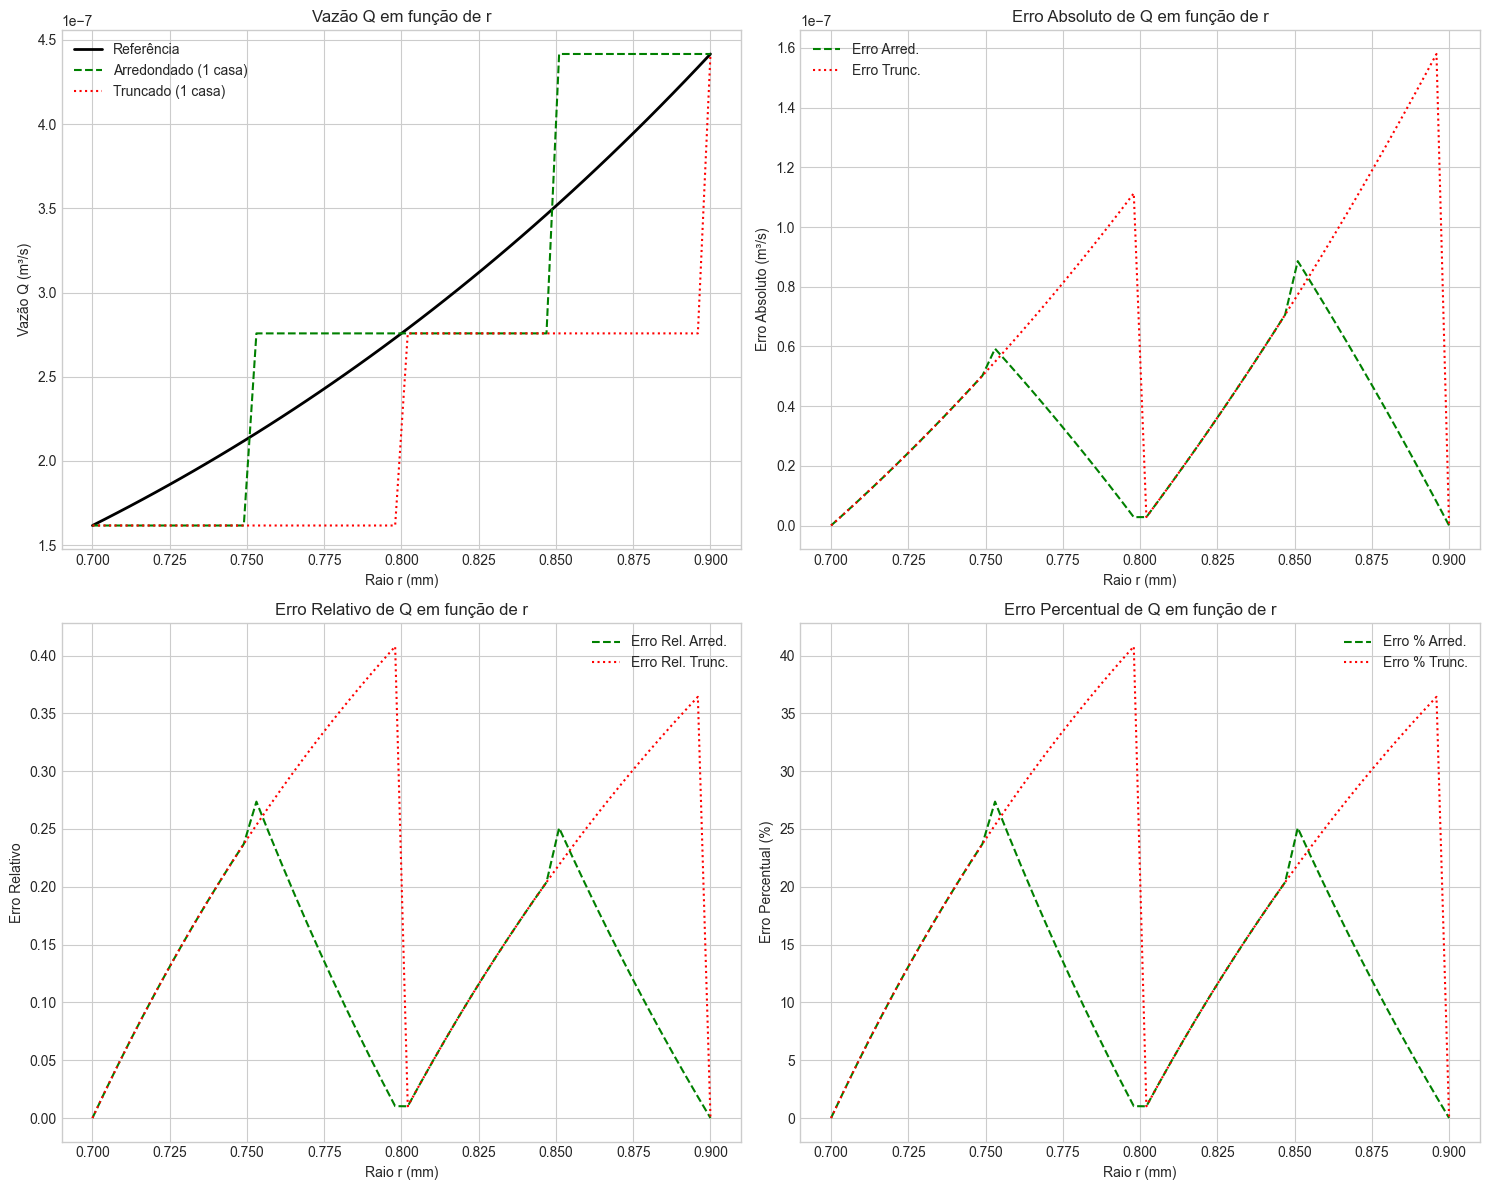

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

axs[0, 0].plot(raios_originais, q_ref, 'k-', label='Referência', linewidth=2)
axs[0, 0].plot(raios_originais, q_arr, 'g--', label='Arredondado (1 casa)')
axs[0, 0].plot(raios_originais, q_tru, 'r:', label='Truncado (1 casa)')
axs[0, 0].set_title('Vazão Q em função de r')
axs[0, 0].set_xlabel('Raio r (mm)')
axs[0, 0].set_ylabel('Vazão Q (m³/s)')
axs[0, 0].legend()

axs[0, 1].plot(raios_originais, erro_abs_arr, 'g--', label='Erro Arred.')
axs[0, 1].plot(raios_originais, erro_abs_tru, 'r:', label='Erro Trunc.')
axs[0, 1].set_title('Erro Absoluto de Q em função de r')
axs[0, 1].set_xlabel('Raio r (mm)')
axs[0, 1].set_ylabel('Erro Absoluto (m³/s)')
axs[0, 1].legend()

axs[1, 0].plot(raios_originais, erro_rel_arr, 'g--', label='Erro Rel. Arred.')
axs[1, 0].plot(raios_originais, erro_rel_tru, 'r:', label='Erro Rel. Trunc.')
axs[1, 0].set_title('Erro Relativo de Q em função de r')
axs[1, 0].set_xlabel('Raio r (mm)')
axs[1, 0].set_ylabel('Erro Relativo')
axs[1, 0].legend()

axs[1, 1].plot(raios_originais, erro_pct_arr, 'g--', label='Erro % Arred.')
axs[1, 1].plot(raios_originais, erro_pct_tru, 'r:', label='Erro % Trunc.')
axs[1, 1].set_title('Erro Percentual de Q em função de r')
axs[1, 1].set_xlabel('Raio r (mm)')
axs[1, 1].set_ylabel('Erro Percentual (%)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

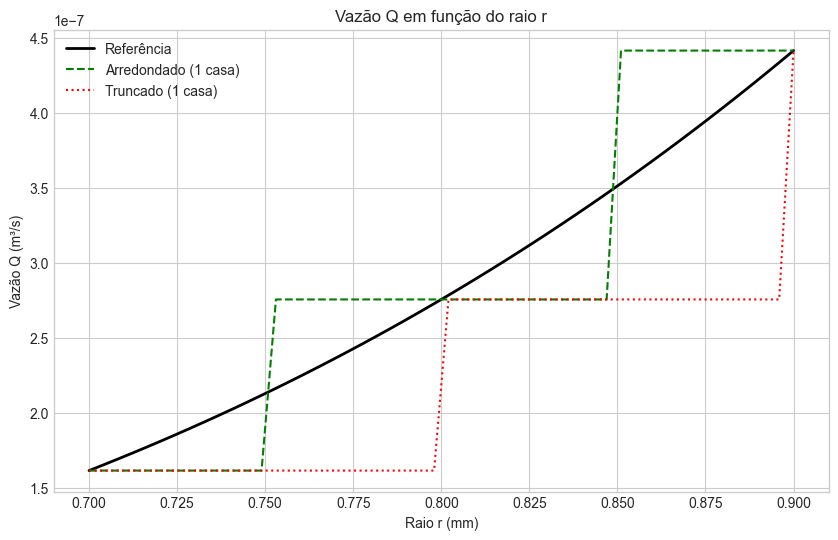

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(raios_originais, q_ref, 'k-', label='Referência', linewidth=2)
plt.plot(raios_originais, q_arr, 'g--', label='Arredondado (1 casa)')
plt.plot(raios_originais, q_tru, 'r:', label='Truncado (1 casa)')
plt.title('Vazão Q em função do raio r')
plt.xlabel('Raio r (mm)')
plt.ylabel('Vazão Q (m³/s)')
plt.legend()
plt.grid(True)
plt.show()

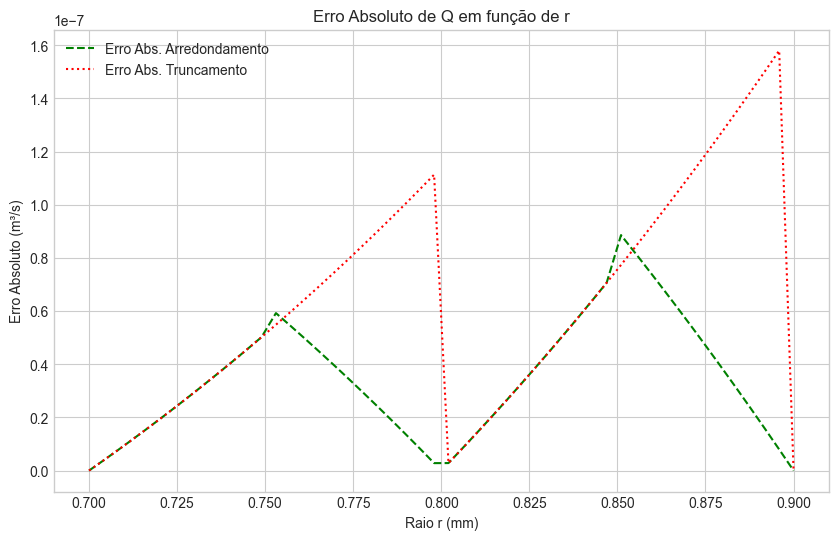

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(raios_originais, erro_abs_arr, 'g--', label='Erro Abs. Arredondamento')
plt.plot(raios_originais, erro_abs_tru, 'r:', label='Erro Abs. Truncamento')
plt.title('Erro Absoluto de Q em função de r')
plt.xlabel('Raio r (mm)')
plt.ylabel('Erro Absoluto (m³/s)')
plt.legend()
plt.grid(True)
plt.show()

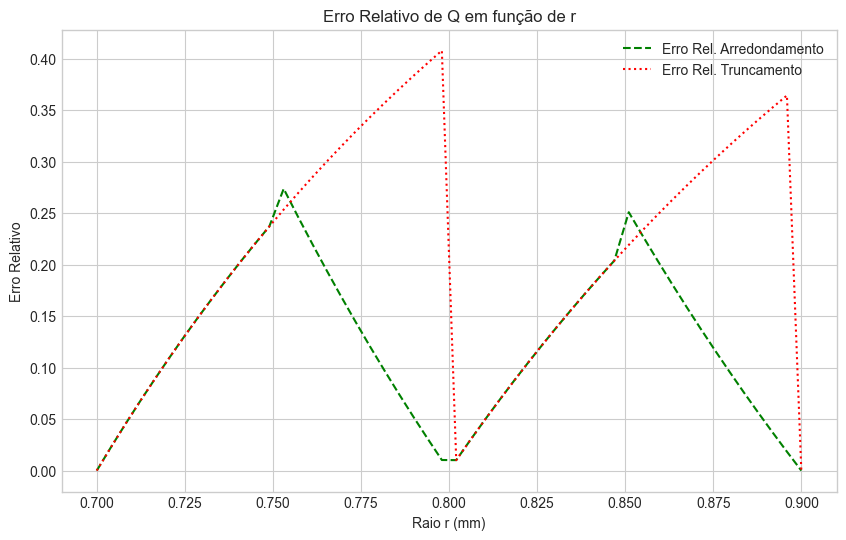

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(raios_originais, erro_rel_arr, 'g--', label='Erro Rel. Arredondamento')
plt.plot(raios_originais, erro_rel_tru, 'r:', label='Erro Rel. Truncamento')
plt.title('Erro Relativo de Q em função de r')
plt.xlabel('Raio r (mm)')
plt.ylabel('Erro Relativo')
plt.legend()
plt.grid(True)
plt.show()

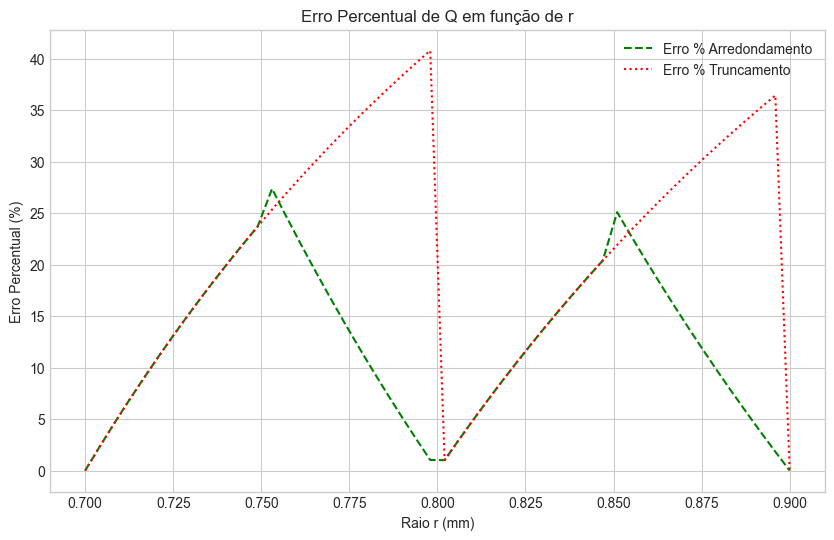

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(raios_originais, erro_pct_arr, 'g--', label='Erro % Arredondamento')
plt.plot(raios_originais, erro_pct_tru, 'r:', label='Erro % Truncamento')
plt.title('Erro Percentual de Q em função de r')
plt.xlabel('Raio r (mm)')
plt.ylabel('Erro Percentual (%)')
plt.legend()
plt.grid(True)
plt.show()

O erro do raio é amplificado na vazão, pois ele está elevado à quarta potência, o que gera uma multiplicação desse erro. Se os dados de entrada contêm pequenas incertezas, as operações propagam essas incertezas, então o erro pode crescer rapidamente. Na prática, como o expoente é quatro, um erro de 1% no raio vira quase 4% de erro na vazão.

# Parte D - Escoamento em um nanocateter

## D.1 - Erro geométrico

In [18]:
import numpy as np
import matplotlib.pyplot as plt

r_nano = 50.0        # raio em nm
L_nano = 10.0        # comprimento em um (micrometros)
mi_nano = 3.5e-3     # viscosidade em Pa.s
delta_p_nano = 5000  # diferenca de pressao em Pa

# Converte a geometria do nanocateter para metros antes de usar a formula.
r_nano_m = r_nano * 1e-9
L_nano_m = L_nano * 1e-6

delta_rs = np.linspace(0.1, 5.0, 50)  # incertezas do raio em nm

Q_nom = calcularQ(r_nano_m, L_nano_m, mi_nano, delta_p_nano)

q_minus = []
q_plus = []
erro_abs_max = []

for dr in delta_rs:
    rm = r_nano - dr
    rp = r_nano + dr
    qm = calcularQ(rm * 1e-9, L_nano_m, mi_nano, delta_p_nano)
    qp = calcularQ(rp * 1e-9, L_nano_m, mi_nano, delta_p_nano)

    q_minus.append(qm)
    q_plus.append(qp)

    erro_abs_max.append(max(abs(qm - Q_nom), abs(qp - Q_nom)))

q_minus = np.array(q_minus)
q_plus = np.array(q_plus)
erro_abs_max = np.array(erro_abs_max)

erro_rel_max = erro_abs_max / Q_nom
erro_pct_max = erro_rel_max * 100

erro_rel_linear = 4 * (delta_rs / r_nano)
erro_pct_linear = erro_rel_linear * 100

print(f"Vazão nominal do nanocateter (r = {r_nano} nm): {Q_nom:.6e} m³/s")

Vazão nominal do nanocateter (r = 50.0 nm): 3.506242e-19 m³/s


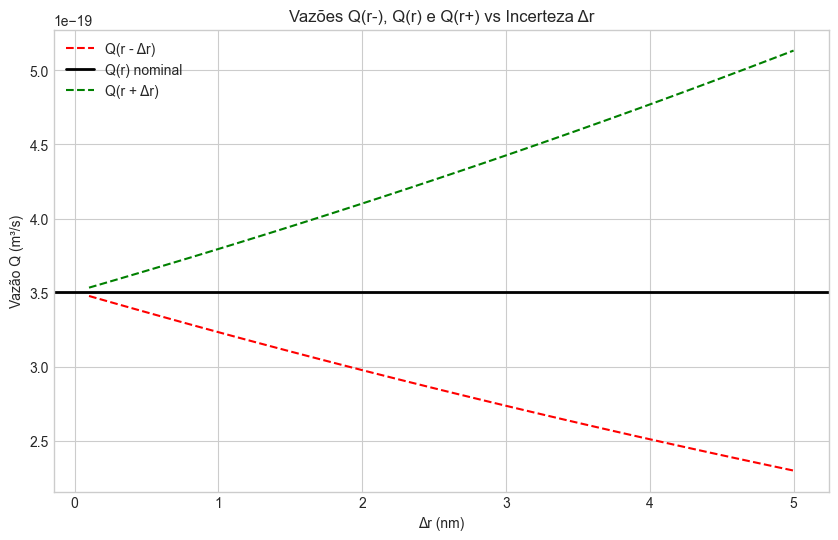

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(delta_rs, q_minus, label='Q(r - Δr)', color='red', linestyle='--')
plt.axhline(y=Q_nom, color='black', label='Q(r) nominal', linewidth=2)
plt.plot(delta_rs, q_plus, label='Q(r + Δr)', color='green', linestyle='--')
plt.title('Vazões Q(r-), Q(r) e Q(r+) vs Incerteza Δr')
plt.xlabel('Δr (nm)')
plt.ylabel('Vazão Q (m³/s)')
plt.legend()
plt.grid(True)
plt.show()

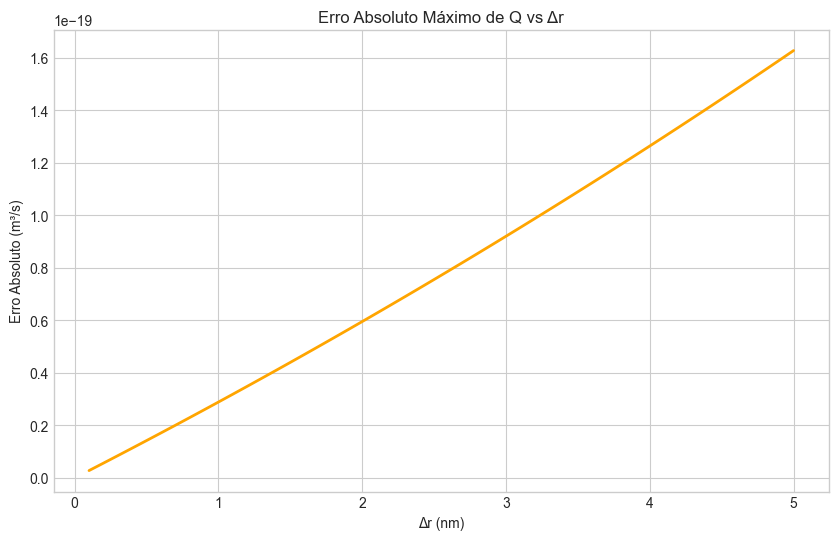

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(delta_rs, erro_abs_max, color='orange', linewidth=2)
plt.title('Erro Absoluto Máximo de Q vs Δr')
plt.xlabel('Δr (nm)')
plt.ylabel('Erro Absoluto (m³/s)')
plt.grid(True)
plt.show()

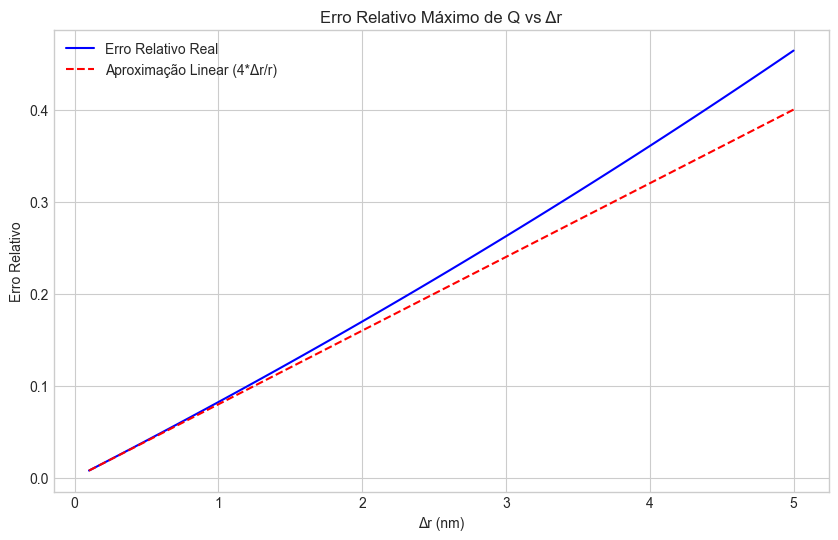

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(delta_rs, erro_rel_max, 'b-', label='Erro Relativo Real')
plt.plot(delta_rs, erro_rel_linear, 'r--', label='Aproximação Linear (4*Δr/r)')
plt.title('Erro Relativo Máximo de Q vs Δr')
plt.xlabel('Δr (nm)')
plt.ylabel('Erro Relativo')
plt.legend()
plt.grid(True)
plt.show()

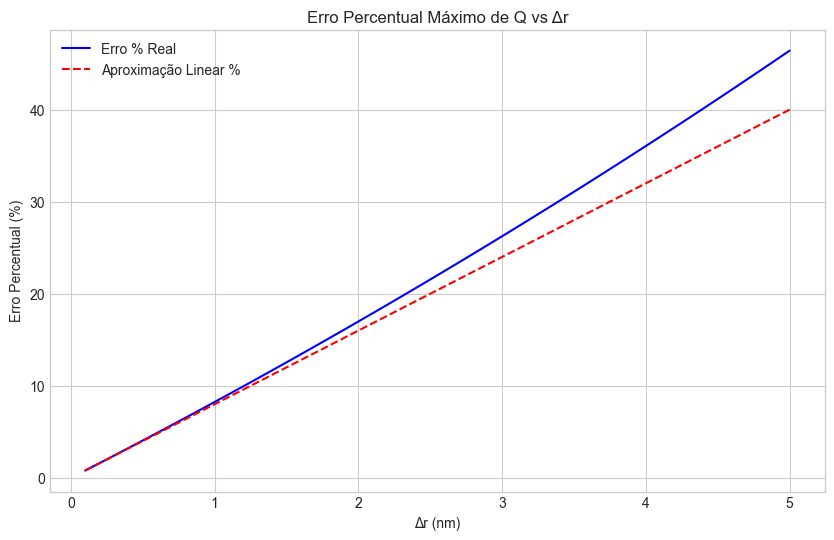

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(delta_rs, erro_pct_max, 'b-', label='Erro % Real')
plt.plot(delta_rs, erro_pct_linear, 'r--', label='Aproximação Linear %')
plt.title('Erro Percentual Máximo de Q vs Δr')
plt.xlabel('Δr (nm)')
plt.ylabel('Erro Percentual (%)')
plt.legend()
plt.grid(True)
plt.show()

## D.2 - Precisão computacional

In [23]:
def calcularQ_precisao(r, L, mi, delta_p, tipo):
  # Converte todas as grandezas para o tipo pedido (float32 ou float64)
  # antes de aplicar Hagen-Poiseuille, para que a conta inteira use a precisao escolhida.
  r = tipo(r)
  L = tipo(L)
  mi = tipo(mi)
  delta_p = tipo(delta_p)
  return tipo(math.pi) * r ** tipo(4) * delta_p / (tipo(8) * L * mi)

r4_32 = np.float32(r_nano_m) ** np.float32(4)
r4_64 = np.float64(r_nano_m) ** np.float64(4)

Q32 = calcularQ_precisao(r_nano_m, L_nano_m, mi_nano, delta_p_nano, np.float32)
Q64 = calcularQ_precisao(r_nano_m, L_nano_m, mi_nano, delta_p_nano, np.float64)

print(f"{'Grandeza':<16} | {'float32':<24} | {'float64':<24}")
print("-" * 70)
print(f"{'r (m)':<16} | {np.float32(r_nano_m):<24.17e} | {np.float64(r_nano_m):<24.17e}")
print(f"{'r^4 (m^4)':<16} | {r4_32:<24.17e} | {r4_64:<24.17e}")
print(f"{'Q (m³/s)':<16} | {Q32:<24.17e} | {Q64:<24.17e}")
print(f"{'eps do tipo':<16} | {np.finfo(np.float32).eps:<24.17e} | {np.finfo(np.float64).eps:<24.17e}")
print()

print("--- Diferença entre as duas precisões (referência = float64) ---")
print(f"r^4  -> Ea = {erro_absoluto(float(r4_64), float(r4_32)):.6e} m⁴ | Er = {erro_relativo(float(r4_64), float(r4_32)):.6e} | E% = {erro_percentual(float(r4_64), float(r4_32)):.6e} %")
print(f"Q    -> Ea = {erro_absoluto(float(Q64), float(Q32)):.6e} m³/s | Er = {erro_relativo(float(Q64), float(Q32)):.6e} | E% = {erro_percentual(float(Q64), float(Q32)):.6e} %")

Grandeza         | float32                  | float64                 
----------------------------------------------------------------------
r (m)            | 5.00000005843048712e-08  | 5.00000000000000044e-08 
r^4 (m^4)        | 6.25000039597742258e-30  | 6.25000000000000192e-30 
Q (m³/s)         | 3.50624232374423395e-19  | 3.50624180088146696e-19 
eps do tipo      | 1.19209289550781250e-07  | 2.22044604925031308e-16 

--- Diferença entre as duas precisões (referência = float64) ---
r^4  -> Ea = 3.959774e-37 m⁴ | Er = 6.335639e-08 | E% = 6.335639e-06 %
Q    -> Ea = 5.228628e-26 m³/s | Er = 1.491234e-07 | E% = 1.491234e-05 %


In [24]:
def delta_1(r, dr, L, mi, delta_p, tipo):
  # Variacao relativa obtida pela diferenca direta de duas vazoes.
  Q_ref = calcularQ_precisao(r, L, mi, delta_p, tipo)
  Q_var = calcularQ_precisao(r + dr, L, mi, delta_p, tipo)
  return (Q_var - Q_ref) / Q_ref


def delta_2(r, dr, tipo):
  # Mesma variacao pela forma algebrica equivalente (1 + dr/r)^4 - 1.
  return (tipo(1) + tipo(dr) / tipo(r)) ** tipo(4) - tipo(1)

razoes = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12]

discrepancias = {}

for tipo, nome_tipo in [(np.float32, "float32"), (np.float64, "float64")]:
    discrepancias[nome_tipo] = []

    print(f"--- Comparação de δ1 e δ2 em {nome_tipo} ---")
    print(f"{'Δr/r':<10} | {'δ1 (diferença direta)':<24} | {'δ2 (forma algébrica)':<24} | {'Er entre δ1 e δ2':<18}")
    print("-" * 86)

    for razao in razoes:
        dr = r_nano_m * razao
        d1 = float(delta_1(r_nano_m, dr, L_nano_m, mi_nano, delta_p_nano, tipo))
        d2 = float(delta_2(r_nano_m, dr, tipo))

        er = erro_relativo(d2, d1)
        discrepancias[nome_tipo].append(er)

        print(f"{razao:<10.0e} | {d1:<24.15e} | {d2:<24.15e} | {er:<18.6e}")

    print()

--- Comparação de δ1 e δ2 em float32 ---
Δr/r       | δ1 (diferença direta)    | δ2 (forma algébrica)     | Er entre δ1 e δ2  
--------------------------------------------------------------------------------------
1e-01      | 4.641000628471375e-01    | 4.641001224517822e-01    | 1.284306e-07      
1e-02      | 4.060374572873116e-02    | 4.060399532318115e-02    | 6.147042e-06      
1e-03      | 4.006010480225086e-03    | 4.006147384643555e-03    | 3.417359e-05      
1e-04      | 3.998785687144846e-04    | 4.001855850219727e-04    | 7.671848e-04      
1e-05      | 4.010581324109808e-05    | 4.005432128906250e-05    | 1.285553e-03      
1e-06      | 3.907367954525398e-06    | 3.814697265625000e-06    | 2.429307e-02      
1e-07      | 2.211717742284236e-07    | 4.768371582031250e-07    | 5.361692e-01      
1e-08      | 0.000000000000000e+00    | 0.000000000000000e+00    | 0.000000e+00      
1e-09      | 0.000000000000000e+00    | 0.000000000000000e+00    | 0.000000e+00      
1e-10      |

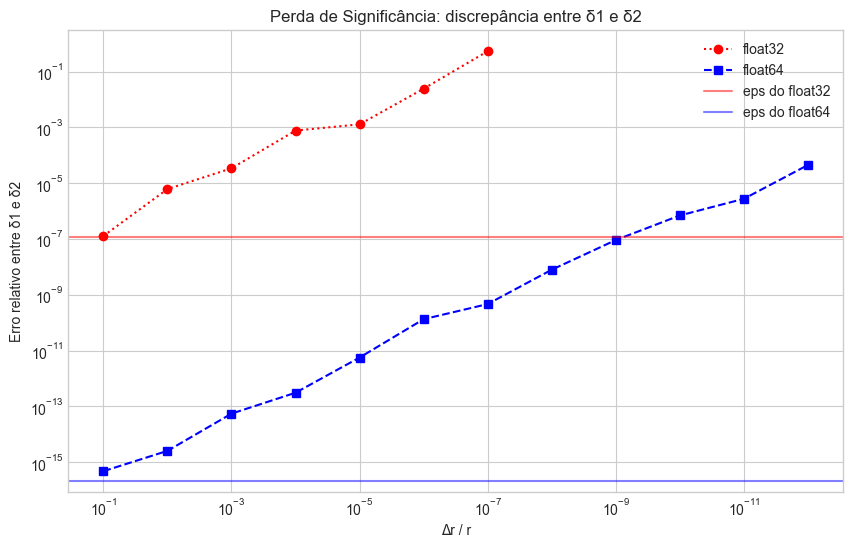

In [25]:
# Uma discrepancia exatamente zero nao pode ser desenhada em escala log:
# vira np.nan para que a curva simplesmente pare onde a precisao acabou.
disc32 = [d if d > 0 else np.nan for d in discrepancias["float32"]]
disc64 = [d if d > 0 else np.nan for d in discrepancias["float64"]]

plt.figure(figsize=(10, 6))

plt.loglog(razoes, disc32, 'r:', marker='o', label='float32')
plt.loglog(razoes, disc64, 'b--', marker='s', label='float64')
plt.axhline(y=np.finfo(np.float32).eps, color='red', alpha=0.5, label='eps do float32')
plt.axhline(y=np.finfo(np.float64).eps, color='blue', alpha=0.5, label='eps do float64')

plt.title('Perda de Significância: discrepância entre δ1 e δ2')
plt.xlabel('Δr / r')
plt.ylabel('Erro relativo entre δ1 e δ2')
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.show()

As duas expressões são iguais na álgebra, mas não são iguais no computador. A δ2 faz só uma subtração no final, com parcelas do mesmo tamanho do resultado, então ela se mantém estável. Já a δ1 subtrai duas vazões quase iguais, e quando Δr/r fica pequeno essa subtração cancela justamente os algarismos significativos que estavam certos, sobrando quase só o erro de representação. Esse é o cancelamento catastrófico.

Na tabela e no gráfico observamos onde cada precisão quebra. Em float32, cujo eps é 1,19e-07, a diferença entre δ1 e δ2 já passa de 10^-3 quando Δr/r é 10^-5, e a partir de 10^-8 as duas contas zeram, porque aí Δr/r fica menor que o próprio eps do tipo. Em float64, cujo eps é 2,22e-16, o mesmo acontece, só que bem mais tarde, perto de Δr/r igual a 10^-12. Ou seja, quando Δr/r é pequeno é melhor usar a δ2, que não subtrai números quase iguais.

## D.3 - Fenômeno físico

Quando descemos do tubo de milímetros para o cateter de nanômetros, a razão superfície/volume cresce como 1/r. Um cilindro de raio r tem área lateral 2πrL e volume πr²L, então essa razão vale 2/r e aumenta muitas ordens de grandeza quando r cai de 0,80 mm para 50 nm. Com isso, uma parte bem maior do fluido fica perto da parede, e os efeitos viscosos e de parede, como o atrito e as interações do líquido com a superfície, deixam de ser detalhes e passam a mandar no escoamento. Nessa escala a própria hipótese de meio contínuo que sustenta Hagen-Poiseuille começa a falhar, e como Q depende de r elevado a quatro, qualquer desvio na geometria é amplificado: um erro de 1 nm em 50 nm já vira cerca de 8% de erro na vazão. Por isso um resultado com muitas casas decimais pode ser preciso na conta e mesmo assim inadequado na física, porque precisão aritmética e validade do modelo são coisas diferentes.

# Parte E - Síntese visual

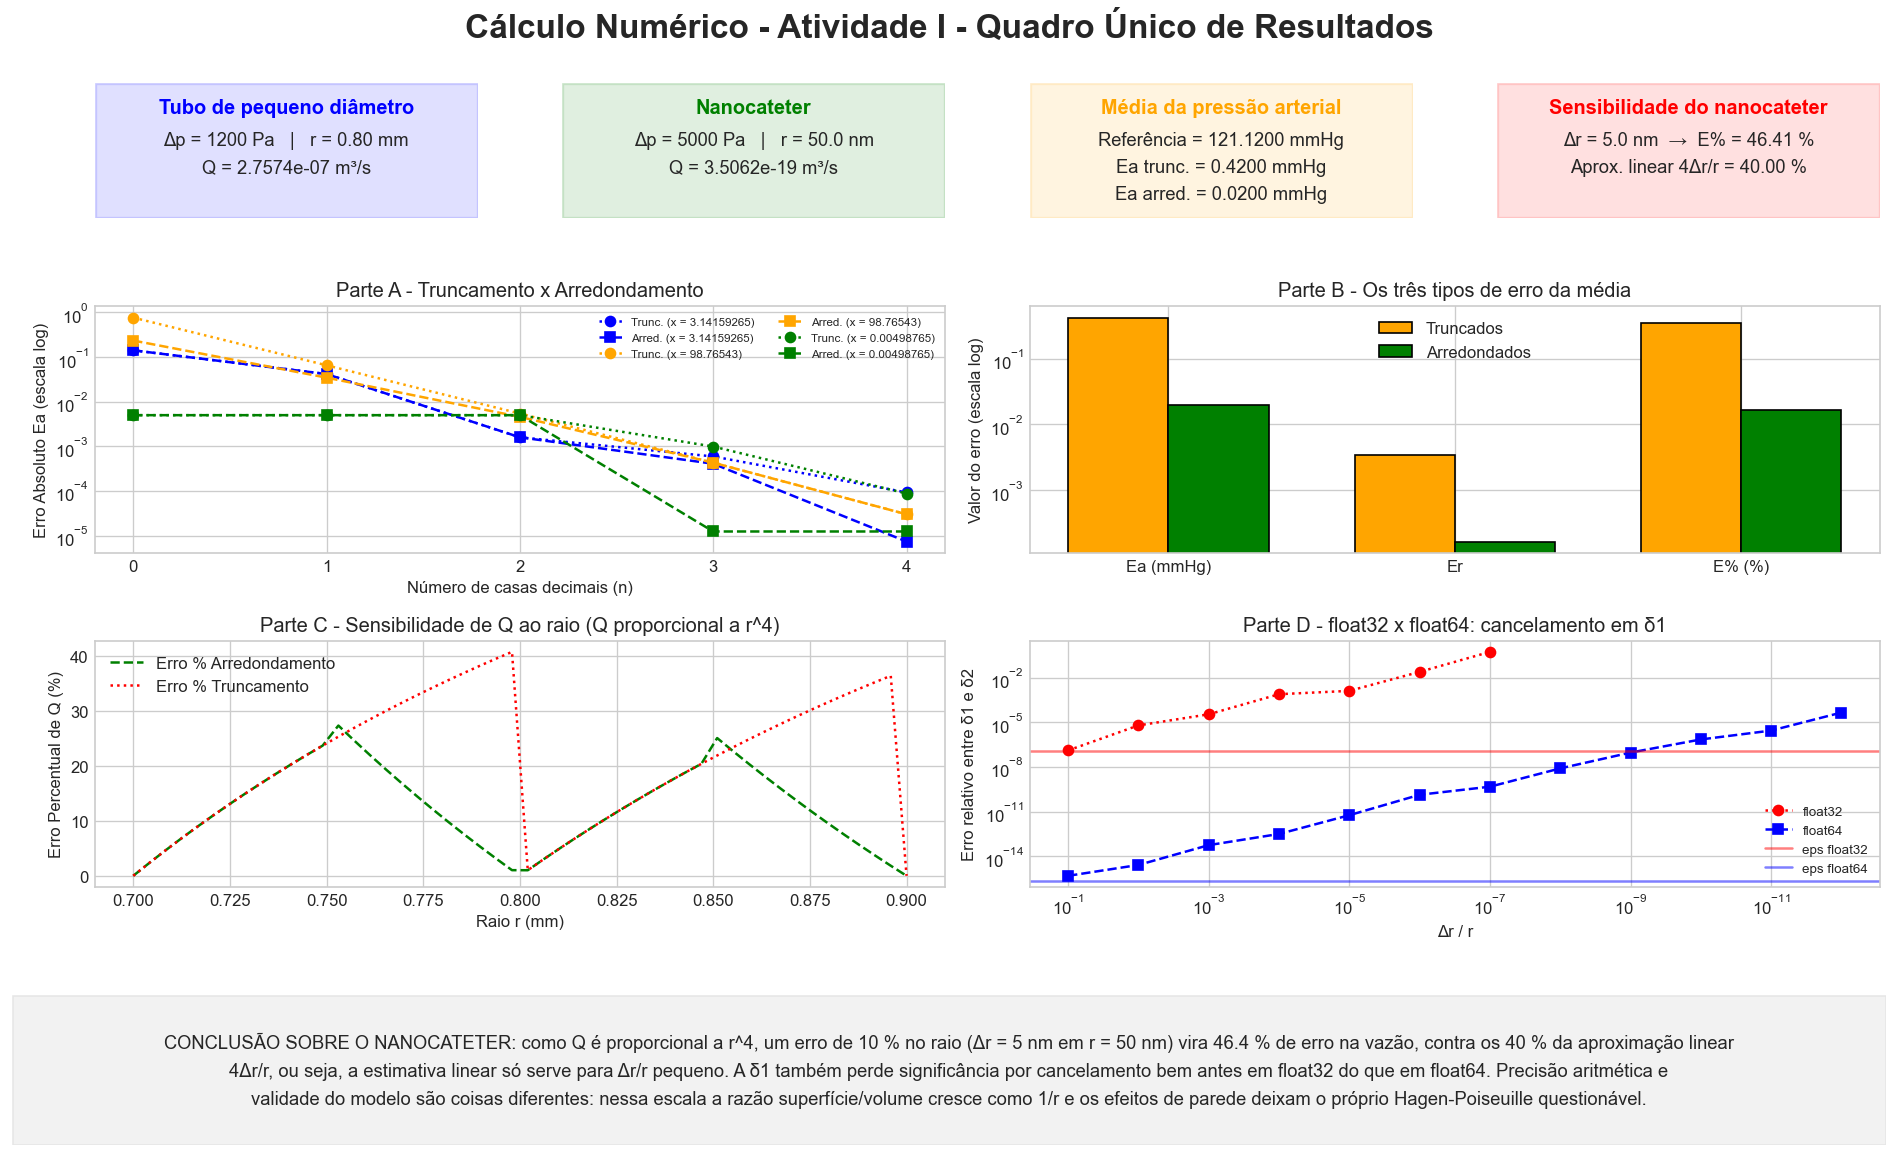

Quadro salvo em 'quadro_resultados.png' com 1920 x 1200 pixels.


In [ ]:
from matplotlib.gridspec import GridSpec
import textwrap

ARQUIVO_PNG = "quadro_resultados.png"

# 16 x 10 polegadas com 120 dpi geram 1920 x 1200 pixels, acima do minimo pedido.
fig = plt.figure(figsize=(16, 10), dpi=120)
fig.suptitle('Cálculo Numérico - Atividade I - Quadro Único de Resultados', fontsize=20, fontweight='bold', y=0.96)

# A grade ocupa a parte de cima; a faixa de conclusao fica embaixo, de ponta a ponta.
grade = GridSpec(3, 4, figure=fig, height_ratios=[0.55, 1.0, 1.0],
                 left=0.055, right=0.985, top=0.90, bottom=0.23, hspace=0.42, wspace=0.22)


def desenhar_cartao(ax, titulo, linhas, cor):
    # Monta um cartao simples: retangulo colorido, titulo em negrito e valores embaixo.
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                               facecolor=cor, alpha=0.12, edgecolor=cor, linewidth=2))
    ax.text(0.5, 0.82, titulo, transform=ax.transAxes, ha='center', va='center',
            fontsize=12, fontweight='bold', color=cor)

    for k, linha in enumerate(linhas):
        ax.text(0.5, 0.58 - k * 0.20, linha, transform=ax.transAxes, ha='center', va='center', fontsize=11)


# --- Linha 1: cartoes com os principais valores de pressao e vazao ---
desenhar_cartao(fig.add_subplot(grade[0, 0]), 'Tubo de pequeno diâmetro',
                [f'Δp = {delta_p} Pa   |   r = {r:.2f} mm',
                 f'Q = {Q_original:.4e} m³/s'], 'blue')

desenhar_cartao(fig.add_subplot(grade[0, 1]), 'Nanocateter',
                [f'Δp = {delta_p_nano} Pa   |   r = {r_nano} nm',
                 f'Q = {Q_nom:.4e} m³/s'], 'green')

desenhar_cartao(fig.add_subplot(grade[0, 2]), 'Média da pressão arterial',
                [f'Referência = {media_referencia:.4f} mmHg',
                 f'Ea trunc. = {erro_absoluto(media_referencia, media(series["Truncados"])):.4f} mmHg',
                 f'Ea arred. = {erro_absoluto(media_referencia, media(series["Arredondados"])):.4f} mmHg'], 'orange')

desenhar_cartao(fig.add_subplot(grade[0, 3]), 'Sensibilidade do nanocateter',
                [f'Δr = {delta_rs[-1]:.1f} nm  →  E% = {erro_pct_max[-1]:.2f} %',
                 f'Aprox. linear 4Δr/r = {erro_pct_linear[-1]:.2f} %'], 'red')

# --- Linha 2, esquerda: truncamento x arredondamento (Parte A) ---
ax_a = fig.add_subplot(grade[1, 0:2])

for j in range(3):
    x = valores[j]
    ea_tru = [erro_absoluto(x, truncar(x, n)) for n in casas]
    ea_arr = [erro_absoluto(x, round(x, n)) for n in casas]

    ax_a.semilogy(casas, ea_tru, color=cores[j], marker='o', linestyle=':', label=f'Trunc. (x = {x})')
    ax_a.semilogy(casas, ea_arr, color=cores[j], marker='s', linestyle='--', label=f'Arred. (x = {x})')

ax_a.set_title('Parte A - Truncamento x Arredondamento')
ax_a.set_xlabel('Número de casas decimais (n)')
ax_a.set_ylabel('Erro Absoluto Ea (escala log)')
ax_a.set_xticks(casas)
ax_a.legend(loc='upper right', fontsize=7, ncol=2)
ax_a.grid(True)

# --- Linha 2, direita: os tres tipos de erro (Parte B) ---
ax_b = fig.add_subplot(grade[1, 2:4])

nomes_erro = ['Ea (mmHg)', 'Er', 'E% (%)']
posicoes = np.arange(len(nomes_erro))
largura = 0.35

for k, nome in enumerate(["Truncados", "Arredondados"]):
    med = media(series[nome])
    alturas = [erro_absoluto(media_referencia, med),
               erro_relativo(media_referencia, med),
               erro_percentual(media_referencia, med)]

    ax_b.bar(posicoes + (k - 0.5) * largura, alturas, largura, label=nome,
             color=['orange', 'green'][k], edgecolor='black')

ax_b.set_yscale('log')
ax_b.set_title('Parte B - Os três tipos de erro da média')
ax_b.set_ylabel('Valor do erro (escala log)')
ax_b.set_xticks(posicoes)
ax_b.set_xticklabels(nomes_erro)
ax_b.legend()
ax_b.grid(True, axis='y')

# --- Linha 3, esquerda: sensibilidade de Q ao raio (Parte C) ---
ax_c = fig.add_subplot(grade[2, 0:2])
ax_c.plot(raios_originais, erro_pct_arr, 'g--', label='Erro % Arredondamento')
ax_c.plot(raios_originais, erro_pct_tru, 'r:', label='Erro % Truncamento')
ax_c.set_title('Parte C - Sensibilidade de Q ao raio (Q proporcional a r^4)')
ax_c.set_xlabel('Raio r (mm)')
ax_c.set_ylabel('Erro Percentual de Q (%)')
ax_c.legend()
ax_c.grid(True)

# --- Linha 3, direita: float32 x float64 (Parte D) ---
ax_d = fig.add_subplot(grade[2, 2:4])
ax_d.loglog(razoes, disc32, 'r:', marker='o', label='float32')
ax_d.loglog(razoes, disc64, 'b--', marker='s', label='float64')
ax_d.axhline(y=np.finfo(np.float32).eps, color='red', alpha=0.5, label='eps float32')
ax_d.axhline(y=np.finfo(np.float64).eps, color='blue', alpha=0.5, label='eps float64')
ax_d.invert_xaxis()
ax_d.set_title('Parte D - float32 x float64: cancelamento em δ1')
ax_d.set_xlabel('Δr / r')
ax_d.set_ylabel('Erro relativo entre δ1 e δ2')
ax_d.legend(fontsize=8)
ax_d.grid(True)

# --- Faixa inferior: conclusao curta sobre o nanocateter, de ponta a ponta ---
ax_txt = fig.add_axes([0.012, 0.015, 0.976, 0.125])
ax_txt.axis('off')
ax_txt.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax_txt.transAxes,
                               facecolor='black', alpha=0.05, edgecolor='black', linewidth=1.5))

conclusao_curta = (
    "CONCLUSÃO SOBRE O NANOCATETER: como Q é proporcional a r^4, um erro de 10 % no raio (Δr = 5 nm em r = 50 nm) vira "
    f"{erro_pct_max[-1]:.1f} % de erro na vazão, contra os {erro_pct_linear[-1]:.0f} % da aproximação linear 4Δr/r, ou seja, "
    "a estimativa linear só serve para Δr/r pequeno. A δ1 também perde significância por cancelamento bem antes em float32 "
    "do que em float64. Precisão aritmética e validade do modelo são coisas diferentes: nessa escala a razão "
    "superfície/volume cresce como 1/r e os efeitos de parede deixam o próprio Hagen-Poiseuille questionável."
)

# Quebra o texto em linhas de largura fixa para ele caber dentro da faixa.
ax_txt.text(0.5, 0.5, textwrap.fill(conclusao_curta, width=175), transform=ax_txt.transAxes,
            ha='center', va='center', fontsize=11, linespacing=1.7)

fig.savefig(ARQUIVO_PNG, dpi=120, facecolor='white')
plt.show()

=from PIL import Image as PILImage

with PILImage.open(ARQUIVO_PNG) as img:
    print(f"Quadro salvo em '{ARQUIVO_PNG}' com {img.size[0]} x {img.size[1]} pixels.")

# GIF demonstrativo

GIF gerado por código com 51 quadros em 'nanocateter.gif'.


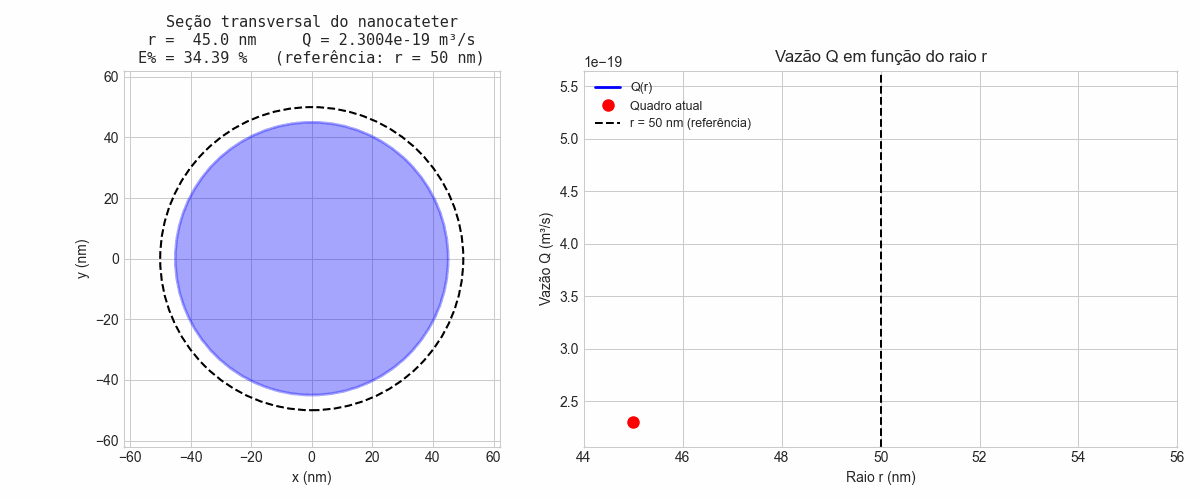

In [27]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

ARQUIVO_GIF = "nanocateter.gif"

# 51 quadros com o raio indo de 45 a 55 nm (passo de 0,2 nm), dentro da faixa de 30 a 60 quadros.
raios_gif = np.linspace(45.0, 55.0, 51)

q_gif = []

for r_val in raios_gif:
    q_gif.append(calcularQ(r_val * 1e-9, L_nano_m, mi_nano, delta_p_nano))

q_gif = np.array(q_gif)

# Erro percentual de cada quadro em relacao ao raio nominal de 50 nm.
erro_pct_gif = np.abs(q_gif - Q_nom) / Q_nom * 100

fig_gif, (ax_secao, ax_curva) = plt.subplots(1, 2, figsize=(12, 5))


def desenhar_quadro(k):
    # Redesenha os dois paineis para o quadro k da animacao.
    ax_secao.clear()
    ax_curva.clear()

    r_atual = raios_gif[k]

    # Painel da esquerda: secao transversal do canal no raio atual.
    ax_secao.add_patch(plt.Circle((0, 0), r_atual, facecolor='blue', alpha=0.35, edgecolor='blue', linewidth=2))
    ax_secao.add_patch(plt.Circle((0, 0), r_nano, facecolor='none', edgecolor='black', linestyle='--', linewidth=1.5))
    ax_secao.set_xlim(-62, 62)
    ax_secao.set_ylim(-62, 62)
    ax_secao.set_aspect('equal')
    ax_secao.set_title('Seção transversal do nanocateter\n'
                       f'r = {r_atual:5.1f} nm     Q = {q_gif[k]:.4e} m³/s\n'
                       f'E% = {erro_pct_gif[k]:5.2f} %   (referência: r = 50 nm)',
                       fontsize=11, fontfamily='monospace')
    ax_secao.set_xlabel('x (nm)')
    ax_secao.set_ylabel('y (nm)')

    # Painel da direita: curva Q x r sendo construida progressivamente.
    ax_curva.plot(raios_gif[:k + 1], q_gif[:k + 1], 'b-', linewidth=2, label='Q(r)')
    ax_curva.plot(raios_gif[k], q_gif[k], 'ro', markersize=8, label='Quadro atual')
    ax_curva.axvline(x=r_nano, color='black', linestyle='--', linewidth=1.5, label='r = 50 nm (referência)')
    ax_curva.set_xlim(44, 56)
    ax_curva.set_ylim(q_gif.min() * 0.9, q_gif.max() * 1.1)
    ax_curva.set_title('Vazão Q em função do raio r')
    ax_curva.set_xlabel('Raio r (nm)')
    ax_curva.set_ylabel('Vazão Q (m³/s)')
    ax_curva.legend(loc='upper left', fontsize=9)
    ax_curva.grid(True)

    fig_gif.tight_layout()


animacao = FuncAnimation(fig_gif, desenhar_quadro, frames=len(raios_gif), interval=100)
animacao.save(ARQUIVO_GIF, writer=PillowWriter(fps=10))
plt.close(fig_gif)

print(f"GIF gerado por código com {len(raios_gif)} quadros em '{ARQUIVO_GIF}'.")
display(Image(filename=ARQUIVO_GIF))

# Conclusão

Nesta atividade observamos que a forma de representar um número já é uma fonte de erro, e que esse erro não se propaga de forma neutra pelas contas. Na Parte A vimos que o arredondamento nunca é pior que o truncamento para a mesma quantidade de casas, porque ele erra no máximo meia unidade da última casa. Na Parte B vimos que arredondar as medidas para inteiros quase não mexe na média, com erro de 0,017%, mas estraga a variabilidade da amostra, ou seja, uma estatística pode sobreviver à aproximação e outra não. Nas Partes C e D o expoente quatro amplificou tudo, porque ΔQ/Q é mais ou menos 4Δr/r, e no nanocateter um Δr de 5 nm sobre 50 nm deu 46,4% de erro na vazão, acima dos 40% da aproximação linear, o que mostra que a linearização só vale para Δr/r pequeno. Na Parte D.2 vimos o lado da máquina: float32 e float64 dão o mesmo Q dentro da precisão de cada um, mas a forma de escrever a conta importa, já que a δ1 perde significância por cancelamento bem antes da δ2. No fim, a conclusão é que precisão aritmética e validade do modelo são coisas diferentes, pois podemos calcular a vazão do nanocateter com muitos dígitos corretos e mesmo assim ter um resultado fisicamente inadequado.